# Study 1 Questionnaire Analysis

This notebook analyzes the SUS, NASA-TLX, Borg CR10, and SSQ scores from `Study1 Questionnaire_15_14.csv` to compare Mid-air (`Case 1`) and Haptic (`Case 2`) conditions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set presentation style
sns.set_theme(style="whitegrid", font_scale=1.2)
plt.rcParams["figure.figsize"] = (8, 6)

## 1. Data Loading and Preparation

First, we load the CSV and set up our columns. We map `Case` 1 to `midair` and `Case` 2 to `haptic` based on timestamps in the experiment data files.

In [2]:
df = pd.read_csv("Study1 Questionnaire_15_14.csv")

# Map Case to Condition
df['Condition'] = df['Case'].map({1: 'midair', 2: 'haptic'})

print(f"Loaded {len(df)} responses across {df['User ID'].nunique()} unique participants.")
display(df[['User ID', 'Condition']].value_counts().unstack(fill_value=0))

Loaded 14 responses across 7 unique participants.


Condition,haptic,midair
User ID,,
1,1,1
2,1,1
3,1,1
4,1,1
5,1,1
6,1,1
7,1,1


## 2. Calculating Scores
### System Usability Scale (SUS)

In [3]:
sus_cols = [
    'I think that I would like to use this system frequently',
    'I found the system unnecessarily complex',
    'I thought the system was easy to use',
    'I think that I would need the support of a technical person to be able to use this system',
    'I found the various functions in this system were well integrated',
    'I thought there was too much inconsistency in this system',
    'I would imagine that most people would learn to use this system very quickly',
    'I found the system very cumbersome to use',
    'I felt very confident using the system',
    'I needed to learn a lot of things before I could get going with this system'
]

def calculate_sus(row):
    score = 0
    for i, col in enumerate(sus_cols):
        val = row[col]
        if (i + 1) % 2 != 0: # Odd numbered item
            score += (val - 1)
        else:                # Even numbered item
            score += (5 - val)
    return score * 2.5

df['SUS Score'] = df.apply(calculate_sus, axis=1)

### NASA-TLX

In [4]:
tlx_cols = [
    'Mental DemandHow mentally demanding was the task?',
    'Physical DemandHow physically demanding was the task?',
    'Temporal DemandHow hurried or rushed was the pace of the task?',
    'PerformanceHow successful were you in accomplishing what you were asked to do? ',
    'EffortHow hard did you have to work to accomplish your level of performance? ',
    'FrustrationHow insecure, discouraged, irritated, stressed,and annoyed were you?'
]

# NASA-TLX is traditionally sum or average. We'll use the unweighted sum here.
df['NASA-TLX Score'] = df[tlx_cols].sum(axis=1)

### Borg CR10
Extract direct value from "How do you measure perceived exertion of effort during using this system?"

In [5]:
df['Borg CR10 Score'] = df['How do you measure perceived exertion of effort during using this system?']

### SSQ (Simulator Sickness Questionnaire)
Standard weights for Kennedy et al. SSQ:
- Nausea (N) = sum(1, 6, 7, 8, 9, 15, 16) * 9.54
- Oculomotor (O) = sum(1, 2, 3, 4, 5, 9, 11) * 7.58
- Disorientation (D) = sum(5, 8, 10, 11, 12, 13, 14) * 13.92
- Total Score (TS) = sum(N/9.54, O/7.58, D/13.92) * 3.74

*Note: Ratings are 1-4 scale in this CSV, needs 0-3 mapping. Item "Fullness of head" (13) is assumed to be 0 as it's missing in the sheet.*

In [6]:
ssq_cols_ordered = [
    'General discomfort',
    'Fatigue',
    'Headache',
    'Eye strain',
    'Difficulty focusing',
    'Increased salivation',
    'Sweating',
    'Nausea',
    'Difficulty concentrating',
    'Fullness of head', # Missing -> will be filled with 0
    'Blurred vision',
    'Dizzy (eyes open)',
    'Dizzy (eyes closed)',
    'Vertigo',
    'Stomach awareness',
    'Burping'
]

# Subtract 1 to map to 0-3, fill missing "Fullness of head" with 0
ssq_raw = pd.DataFrame(index=df.index)
for i, col in enumerate(ssq_cols_ordered):
    if col == 'Fullness of head':
        ssq_raw[f"item_{i+1}"] = 0
    else:
        ssq_raw[f"item_{i+1}"] = df[col] - 1

# Calculate N, O, D subscales
# N: [1, 6, 7, 8, 9, 15, 16]
# O: [1, 2, 3, 4, 5, 9, 11]
# D: [5, 8, 10, 11, 12, 13, 14]
n_cols = ['item_1', 'item_6', 'item_7', 'item_8', 'item_9', 'item_15', 'item_16']
o_cols = ['item_1', 'item_2', 'item_3', 'item_4', 'item_5', 'item_9', 'item_11']
d_cols = ['item_5', 'item_8', 'item_10', 'item_11', 'item_12', 'item_13', 'item_14']

ssq_n = ssq_raw[n_cols].sum(axis=1)
ssq_o = ssq_raw[o_cols].sum(axis=1)
ssq_d = ssq_raw[d_cols].sum(axis=1)

df['SSQ Nausea'] = ssq_n * 9.54
df['SSQ Oculomotor'] = ssq_o * 7.58
df['SSQ Disorientation'] = ssq_d * 13.92
df['SSQ Total Score'] = (ssq_n + ssq_o + ssq_d) * 3.74


## 3. Visualization and Statistical Testing

/var/folders/tt/bgyw0f8n6x5bnkssjs8qq5n00000gn/T/ipykernel_50100/1199905383.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Condition', y=metric, ax=ax, width=0.4, palette='Set2')
/var/folders/tt/bgyw0f8n6x5bnkssjs8qq5n00000gn/T/ipykernel_50100/1199905383.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Condition', y=metric, ax=ax, width=0.4, palette='Set2')
/var/folders/tt/bgyw0f8n6x5bnkssjs8qq5n00000gn/T/ipykernel_50100/1199905383.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Condition', 

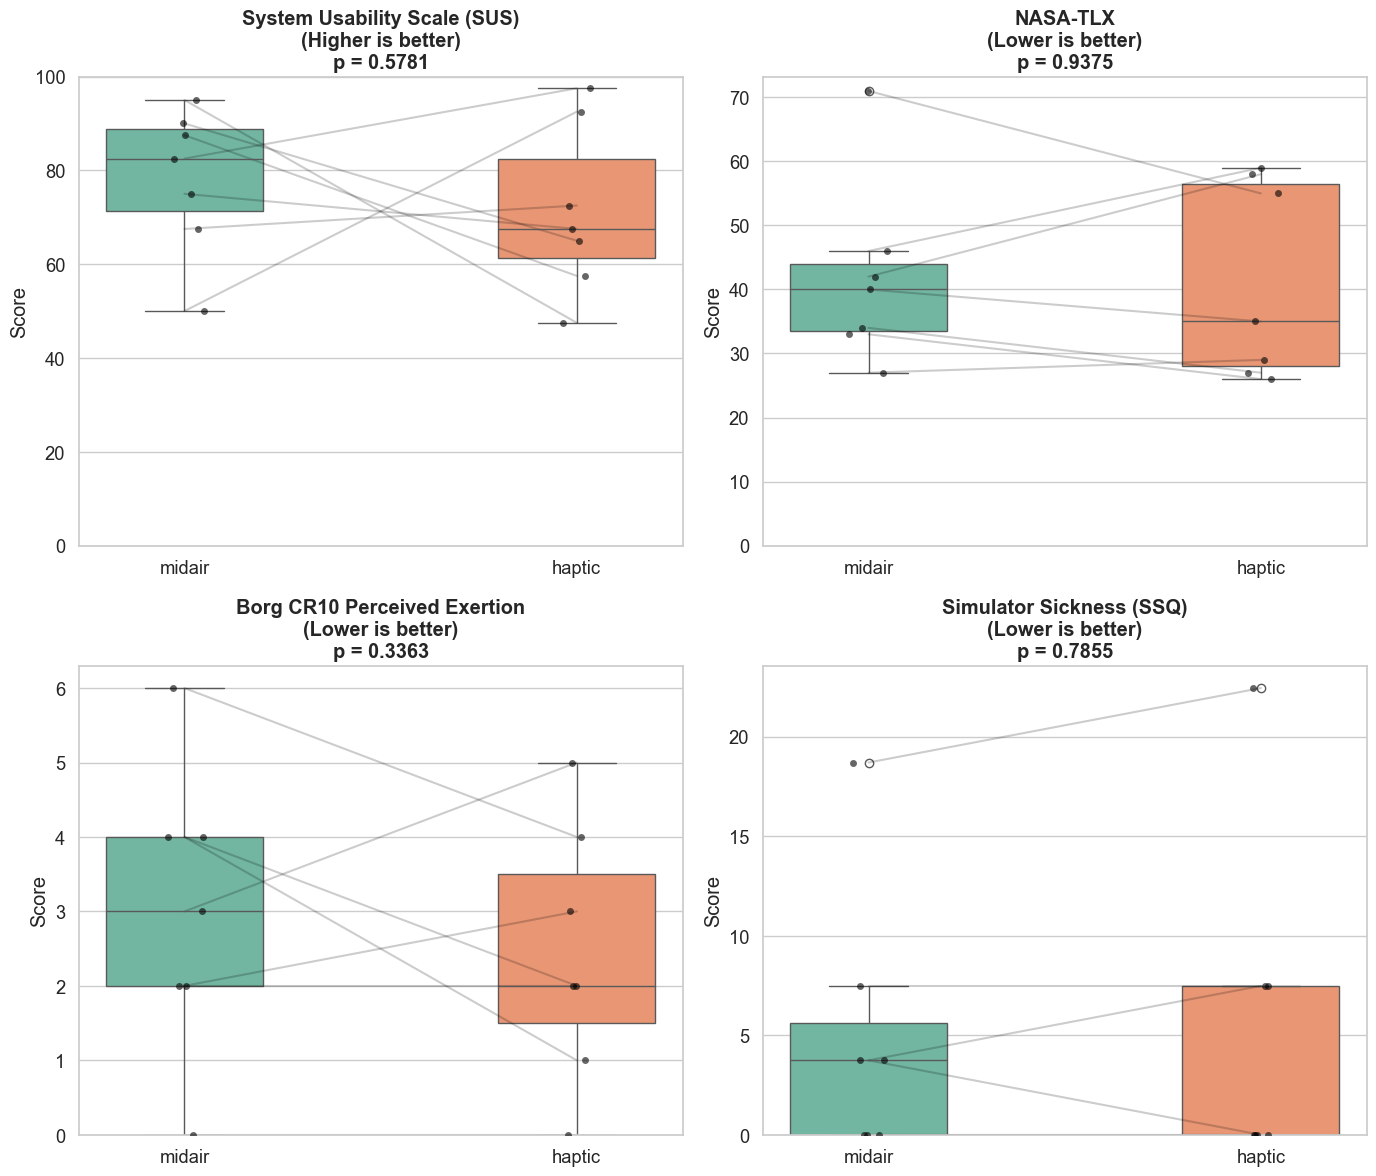

,Metric,midair Mean,midair SD,haptic Mean,haptic SD,p-value,Significant
0,SUS Score,78.214,15.526,71.429,18.020,0.578,False
1,NASA-TLX Score,41.857,14.323,41.286,15.327,0.938,False
2,Borg CR10 Score,3.000,1.915,2.429,1.718,0.336,False
3,SSQ Total Score,4.809,6.730,5.343,8.323,0.785,False


In [8]:
metrics = ['SUS Score', 'NASA-TLX Score', 'Borg CR10 Score', 'SSQ Total Score']

# Aggregate metric list
metric_titles = {
    'SUS Score': 'System Usability Scale (SUS)\n(Higher is better)',
    'NASA-TLX Score': 'NASA-TLX\n(Lower is better)',
    'Borg CR10 Score': 'Borg CR10 Perceived Exertion\n(Lower is better)',
    'SSQ Total Score': 'Simulator Sickness (SSQ)\n(Lower is better)'
}

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

results = []

# Convert to pivot table to ensure paired subjects line up
paired_df = df.pivot(index='User ID', columns='Condition', values=metrics)
paired_df = paired_df.dropna()

for i, metric in enumerate(metrics):
    ax = axes[i]
    
    # Subplot
    sns.boxplot(data=df, x='Condition', y=metric, ax=ax, width=0.4, palette='Set2')
    sns.stripplot(data=df, x='Condition', y=metric, ax=ax, color='black', alpha=0.6, jitter=0.05)
    
    # Connect lines for pairs
    for user in paired_df.index:
        val1 = paired_df.loc[user, (metric, 'midair')]
        val2 = paired_df.loc[user, (metric, 'haptic')]
        ax.plot([0, 1], [val1, val2], c='black', alpha=0.2)
        
    ax.set_ylim(bottom=0)
    
    # Stats
    midair_vals = paired_df[(metric, 'midair')]
    haptic_vals = paired_df[(metric, 'haptic')]
    
    if len(midair_vals) > 0 and (midair_vals != haptic_vals).any():
        # Wilcoxon signed-rank test (paired non-parametric)
        stat, pval = stats.wilcoxon(midair_vals, haptic_vals)
    else:
        pval = 1.0
        
    results.append({
        'Metric': metric, 
        'midair Mean': midair_vals.mean(), 
        'midair SD': midair_vals.std(),
        'haptic Mean': haptic_vals.mean(),
        'haptic SD': haptic_vals.std(),
        'p-value': pval
    })
    
    # Title and annotating p-value
    ax.set_title(f"{metric_titles[metric]}\np = {pval:.4f}", fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Score')

plt.tight_layout()
plt.savefig('study1_questionnaire_results.png', dpi=300)
plt.show()

# Display results table
res_df = pd.DataFrame(results)
res_df['Significant'] = res_df['p-value'] < 0.05
display(res_df.round(3))

In [10]:
# 如果报错提示找不到 statsmodels，请在终端或新建单元格运行：!pip install statsmodels
import pandas as pd
import numpy as np
from scipy.stats import rankdata
from statsmodels.stats.anova import AnovaRM

art_results = []

# 确保我们要分析的列在 df 里
metrics = ['SUS Score', 'NASA-TLX Score', 'Borg CR10 Score', 'SSQ Total Score']

# 1. 把宽格式 (Wide format) 的数据转成适合 ANOVA 的长格式 (Long format)
df_long = df.melt(id_vars=['User ID', 'Condition'], value_vars=metrics, var_name='Metric', value_name='Score')

for metric in metrics:
    # 筛选单个指标，并去除缺失值
    df_metric = df_long[df_long['Metric'] == metric].dropna().copy()
    
    # 2. Aligned Rank Transform (ART) 核心步骤
    # 在单因素重复测量设计下，ART 就等价于对所有条件和受试者的整体数据求秩(Rank)
    df_metric['Ranked_Score'] = rankdata(df_metric['Score'])
    
    # 3. 对求得的秩 (Rank) 执行重复测量 ANOVA
    try:
        # aggregate_func='mean' 可以在不小心出现某 User 存在重复 Condition 数据时避免报错
        anova = AnovaRM(data=df_metric, depvar='Ranked_Score', subject='User ID', 
                        within=['Condition'], aggregate_func='mean').fit()
        f_val = anova.anova_table.loc['Condition', 'F Value']
        p_val = anova.anova_table.loc['Condition', 'Pr > F']
    except Exception as e:
        print(f"Error computing ART ANOVA for {metric}: {e}")
        f_val = np.nan
        p_val = np.nan
        
    art_results.append({
        'Metric': metric,
        'ART F-Value': f_val,
        'ART p-value': pval,
        'Significant (p < 0.05)': p_val < 0.05
    })

# 输出 ART ANOVA 的结果表
art_df = pd.DataFrame(art_results)
display(art_df.round(4))


Error computing ART ANOVA for SUS Score: invalid syntax (<unknown>, line 1)
Error computing ART ANOVA for NASA-TLX Score: invalid syntax (<unknown>, line 1)
Error computing ART ANOVA for Borg CR10 Score: invalid syntax (<unknown>, line 1)
Error computing ART ANOVA for SSQ Total Score: invalid syntax (<unknown>, line 1)


,Metric,ART F-Value,ART p-value,Significant (p < 0.05)
0,SUS Score,NaN,0.7855,False
1,NASA-TLX Score,NaN,0.7855,False
2,Borg CR10 Score,NaN,0.7855,False
3,SSQ Total Score,NaN,0.7855,False
